# 01 - Exploratory Data Analysis: Ride-Hailing (Uber & Lyft)

In [1]:
# 1. Imports and visualization settings
# We import pandas for tabular data handling, numpy for numeric operations,
# and matplotlib/seaborn for data visualization.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean aesthetic style and floating point display formatting
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

print("Libraries imported and visual styling initialized.")


Libraries imported and visual styling initialized.


In [2]:
# 2. Load the Boston Uber & Lyft dataset
# This dataset contains historical ride observations with distance, cab type, product tier, and surge pricing.
df = pd.read_csv("../data/raw/ride/uber_lyft_boston.csv")

print(f"Dataset Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print("\nColumn Names in this dataset:")
print(list(df.columns))

# Display top 5 rows
df.head()


Dataset Shape: 693,071 rows, 10 columns

Column Names in this dataset:
['distance', 'cab_type', 'time_stamp', 'destination', 'source', 'price', 'surge_multiplier', 'id', 'product_id', 'name']


,distance,cab_type,time_stamp,destination,source,price,surge_multiplier,id,product_id,name
0,0.44,Lyft,1544952607890,North Station,Haymarket Square,5.00,1.00,424553bb-7174-41ea-aeb4-fe06d4f4b9d7,lyft_line,Shared
1,0.44,Lyft,1543284023677,North Station,Haymarket Square,11.00,1.00,4bd23055-6827-41c6-b23b-3c491f24e74d,lyft_premier,Lux
2,0.44,Lyft,1543366822198,North Station,Haymarket Square,7.00,1.00,981a3613-77af-4620-a42a-0c0866077d1e,lyft,Lyft
3,0.44,Lyft,1543553582749,North Station,Haymarket Square,26.00,1.00,c2d88af2-d278-4bfd-a8d0-29ca77cc5512,lyft_luxsuv,Lux Black XL
4,0.44,Lyft,1543463360223,North Station,Haymarket Square,9.00,1.00,e0126e1f-8ca9-4f2e-82b3-50505a09db9a,lyft_plus,Lyft XL


In [3]:
# 3. Handle datetime and timestamp conversion
# Note: In this dataset, the column is named time_stamp (with underscore) and is in milliseconds.
# We convert it to a pandas datetime object and derive hour, day, and month columns.
if "time_stamp" in df.columns:
    # Timestamp is in milliseconds if values exceed 1e11, else seconds
    unit = "ms" if df["time_stamp"].max() > 1e11 else "s"
    df["datetime"] = pd.to_datetime(df["time_stamp"], unit=unit)
    df["hour"] = df["datetime"].dt.hour
    df["day"] = df["datetime"].dt.day
    df["month"] = df["datetime"].dt.month
    df["day_name"] = df["datetime"].dt.day_name()
    print("Derived datetime, hour, day, month, and day_name from time_stamp successfully.")

print("\nSample temporal columns:")
df[["time_stamp", "datetime", "hour", "day", "month", "day_name"]].head()


Derived datetime, hour, day, month, and day_name from time_stamp successfully.

Sample temporal columns:


,time_stamp,datetime,hour,day,month,day_name
0,1544952607890,2018-12-16 09:30:07.890,9,16,12,Sunday
1,1543284023677,2018-11-27 02:00:23.677,2,27,11,Tuesday
2,1543366822198,2018-11-28 01:00:22.198,1,28,11,Wednesday
3,1543553582749,2018-11-30 04:53:02.749,4,30,11,Friday
4,1543463360223,2018-11-29 03:49:20.223,3,29,11,Thursday


In [4]:
# 4. Check for missing values and understand why they exist
# In ride-hailing datasets, Taxi rides often have null price quotes because they are metered in the cab.
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_summary = pd.DataFrame({"Missing Count": null_counts, "Missing Pct (%)": null_pct})

print("Columns with missing values:")
display(null_summary[null_summary["Missing Count"] > 0])

# Verify which ride types have missing prices
taxi_missing = df[df["price"].isnull()]["name"].value_counts()
print("\nRide services with missing prices:\n", taxi_missing)


Columns with missing values:


,Missing Count,Missing Pct (%)
price,55095,7.95



Ride services with missing prices:
 name
Taxi    55095
Name: count, dtype: int64


In [5]:
# 5. Data cleaning: filter out null prices
# For fare prediction modeling, we need known upfront price labels, so we drop null price rows.
clean_df = df.dropna(subset=["price"]).copy()
print(f"Cleaned dataset has {len(clean_df):,} valid ride records with upfront pricing.")


Cleaned dataset has 637,976 valid ride records with upfront pricing.


In [6]:
# 6. Summary statistics across cab types and vehicle tiers
# Inspect average price, distance, and surge rate across platforms (Uber vs. Lyft) and vehicle categories.
print("Numerical Columns Summary:")
display(clean_df[["price", "distance", "surge_multiplier"]].describe())

# Group by cab platform and vehicle tier (Shared, UberX, Black, Lux, etc.)
tier_summary = clean_df.groupby(["cab_type", "name"]).agg(
    avg_price=("price", "mean"),
    median_price=("price", "median"),
    avg_distance=("distance", "mean"),
    pct_surged=("surge_multiplier", lambda s: (s > 1.0).mean() * 100),
    total_rides=("id", "count")
).reset_index().sort_values("avg_price", ascending=False)

print("\nSummary by Cab Type & Vehicle Tier:")
display(tier_summary)


Numerical Columns Summary:


,price,distance,surge_multiplier
count,637976.00,637976.00,637976.00
mean,16.55,2.19,1.02
std,9.32,1.14,0.10
min,2.50,0.02,1.00
25%,9.00,1.27,1.00
50%,13.50,2.16,1.00
75%,22.50,2.93,1.00
max,97.50,7.86,3.00



Summary by Cab Type & Vehicle Tier:


,cab_type,name,avg_price,median_price,avg_distance,pct_surged,total_rides
2,Lyft,Lux Black XL,32.32,30.00,2.19,8.19,51235
7,Uber,Black SUV,30.29,28.50,2.19,0.00,55096
1,Lyft,Lux Black,23.06,22.50,2.19,8.19,51235
6,Uber,Black,20.52,19.50,2.19,0.00,55095
0,Lyft,Lux,17.77,16.50,2.19,8.19,51235
10,Uber,UberXL,15.68,15.00,2.19,0.00,55096
4,Lyft,Lyft XL,15.31,13.50,2.19,8.19,51235
9,Uber,UberX,9.77,9.50,2.19,0.00,55094
11,Uber,WAV,9.77,9.50,2.19,0.00,55096
3,Lyft,Lyft,9.61,9.00,2.19,8.19,51235


/tmp/ipykernel_31373/807298527.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=surge_counts.index, y=surge_counts.values, ax=axes[1], palette="magma")


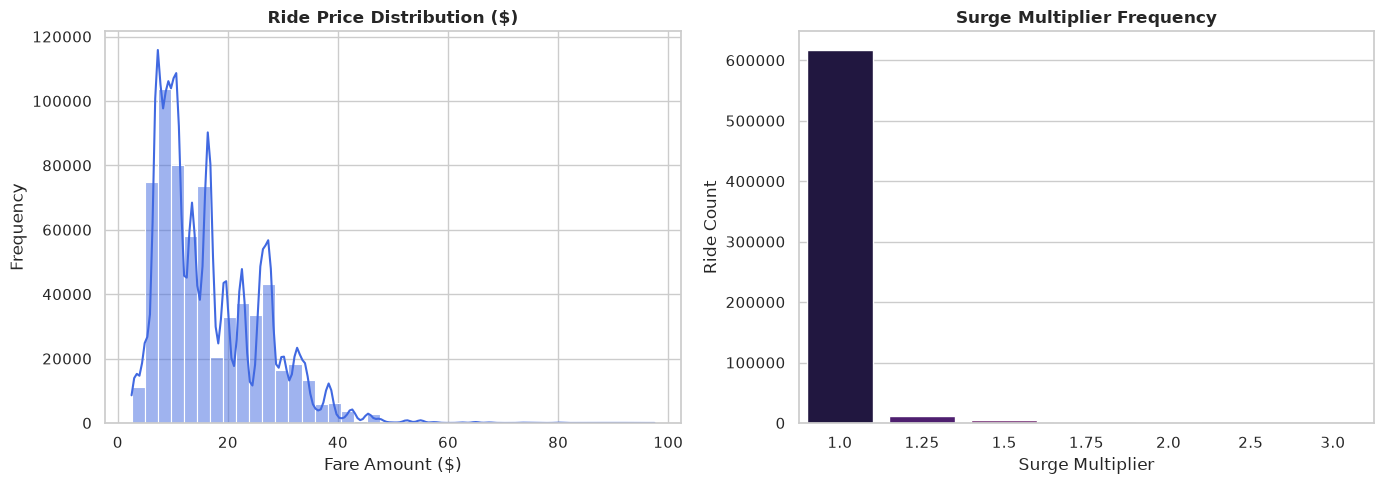

Surge Multiplier Breakdown:
surge_multiplier
1.00    617001
1.25     11085
1.50      5065
1.75      2420
2.00      2239
2.50       154
3.00        12
Name: count, dtype: int64


In [7]:
# 7. Distribution of Ride Fare and Surge Multiplier
# Fares are typically right-skewed; surge multipliers are predominantly 1.0x with spikes during high demand.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot price histogram with KDE curve
sns.histplot(clean_df["price"], bins=40, kde=True, ax=axes[0], color="royalblue")
axes[0].set_title("Ride Price Distribution ($)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Fare Amount ($)")
axes[0].set_ylabel("Frequency")

# Plot surge multiplier distribution
surge_counts = clean_df["surge_multiplier"].value_counts().sort_index()
sns.barplot(x=surge_counts.index, y=surge_counts.values, ax=axes[1], palette="magma")
axes[1].set_title("Surge Multiplier Frequency", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Surge Multiplier")
axes[1].set_ylabel("Ride Count")

plt.tight_layout()
plt.show()

print("Surge Multiplier Breakdown:")
print(surge_counts)


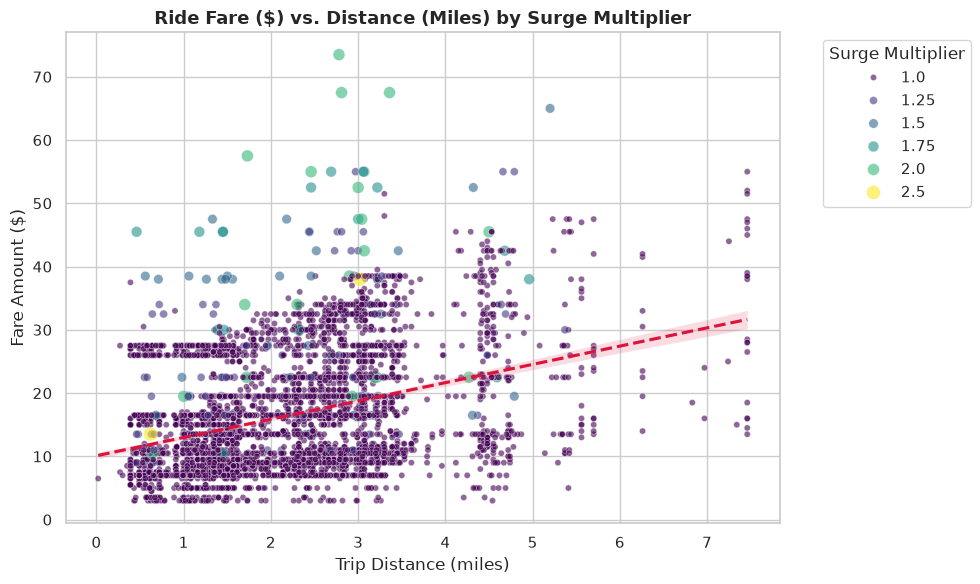

In [8]:
# 8. Distance vs. Price Dynamics with Surge Multiplier
# We sample 5,000 rides for responsive plotting to observe how price scales with distance and surge.
sample_df = clean_df.sample(n=min(5000, len(clean_df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_df,
    x="distance",
    y="price",
    hue="surge_multiplier",
    palette="viridis",
    alpha=0.6,
    size="surge_multiplier",
    sizes=(20, 100)
)

# Plot overall linear trend line
sns.regplot(
    data=sample_df,
    x="distance",
    y="price",
    scatter=False,
    color="crimson",
    line_kws={"linestyle": "--", "label": "Mean Base Trend"}
)

plt.title("Ride Fare ($) vs. Distance (Miles) by Surge Multiplier", fontsize=13, fontweight="bold")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount ($)")
plt.legend(title="Surge Multiplier", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


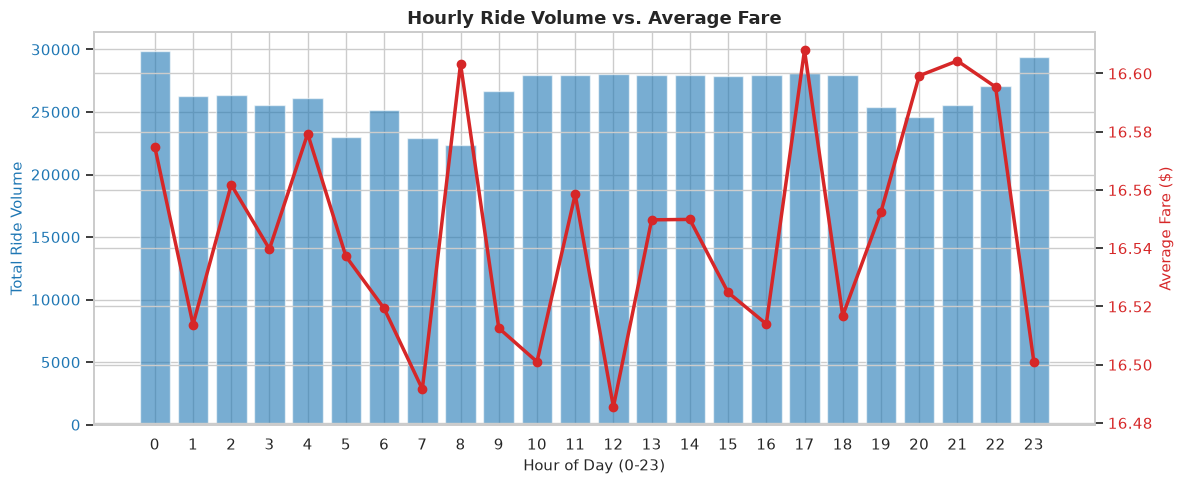

In [9]:
# 9. Temporal Trends: Hourly Ride Volume and Average Pricing
# Examine how ride volume and average fare fluctuate throughout the 24 hours of the day.
hourly_stats = clean_df.groupby("hour").agg(
    total_rides=("id", "count"),
    mean_price=("price", "mean")
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot ride volume bars
color = "tab:blue"
ax1.set_xlabel("Hour of Day (0-23)", fontsize=11)
ax1.set_ylabel("Total Ride Volume", color=color, fontsize=11)
ax1.bar(hourly_stats["hour"], hourly_stats["total_rides"], color=color, alpha=0.6)
ax1.tick_params(axis="y", labelcolor=color)

# Plot average fare on secondary y-axis
ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Average Fare ($)", color=color, fontsize=11)
ax2.plot(hourly_stats["hour"], hourly_stats["mean_price"], color=color, marker="o", linewidth=2.5)
ax2.tick_params(axis="y", labelcolor=color)

plt.title("Hourly Ride Volume vs. Average Fare", fontsize=13, fontweight="bold")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


In [10]:
# 10. Inspect secondary GPS coordinate dataset (uber_fares.csv)
# Check the structure of GPS pickup/dropoff coordinates for Haversine distance modeling.
gps_df = pd.read_csv("../data/raw/ride/uber_fares.csv", nrows=5000)
print(f"GPS Fares Sample Shape: {gps_df.shape}")
print("GPS Fares Columns:", list(gps_df.columns))
display(gps_df[["fare_amount", "pickup_longitude", "pickup_latitude", "dropoff_longitude", "dropoff_latitude", "passenger_count"]].head())


GPS Fares Sample Shape: (5000, 9)
GPS Fares Columns: ['Unnamed: 0', 'key', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.50,-74.00,40.74,-74.00,40.72,1
1,7.70,-73.99,40.73,-73.99,40.75,1
2,12.90,-74.01,40.74,-73.96,40.77,1
3,5.30,-73.98,40.79,-73.97,40.80,3
4,16.00,-73.93,40.74,-73.97,40.76,5
